# H7 — Boundary Position × Condition (Mixed-Model ANOVA)

**Test:** Mixed-Model ANOVA (within: boundary position; between: condition)  
**Question:** Does where an item appeared (Pre/Mid/Post) affect REC or LDI? Does it interact with condition?  
**Hypothesis:** Boundary position significantly affects REC/LDI, with a potential condition interaction.

In [1]:
import warnings
import numpy as np
import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def _header(title, width=75):
    print("\n" + "═" * width)
    print(f"  {title}")
    print("═" * width)

def _get_p(row):
    for c in row.index:
        if c in ("p-unc", "p-val", "p_val", "p_unc", "p"):
            return float(row[c])
    raise KeyError(f"No p-value column. Available: {list(row.index)}")

def _get_corr_p(cor_df):
    for c in cor_df.columns:
        if c in ("p-val", "p_val", "pval", "p"):
            return float(cor_df[c].values[0])
    raise KeyError(f"No corr p column. Available: {list(cor_df.columns)}")

def _sig(p):
    return "✅ Significant" if p < 0.05 else "❌ Not Significant"


In [3]:
CSV_PATH = "compiled_preprocessed.csv"   # <-- change this to your file path

df = pd.read_csv(CSV_PATH)

# Handle naming differences across preprocess versions.
col_candidates = {
    "participant": ["participant_uid", "participant_id", "Participant_ID"],
    "condition": ["condition", "Condition"],
    "trial_type": ["trial_type", "Trial_Type"],
    "response": ["user_response", "response", "User_Response"],
    "position": ["boundary_position", "Boundary_Position"],
    "rt": ["encoding_RT", "Encoding_RT", "encoding_rt", "Encoding_rt", "RT_encoding", "RT"],
}

resolved = {}
for key, candidates in col_candidates.items():
    resolved[key] = next((c for c in candidates if c in df.columns), None)

required_keys = ["participant", "condition", "trial_type", "response", "position"]
missing = [k for k in required_keys if resolved[k] is None]
if missing:
    raise ValueError(f"Missing required columns for {missing}. Found columns: {list(df.columns)}")

if resolved["rt"] is not None:
    df["Encoding_RT"] = pd.to_numeric(df[resolved["rt"]], errors="coerce")
else:
    df["Encoding_RT"] = np.nan
    print("Warning: No encoding RT column found; Encoding_RT set to NaN.")

pid_col = resolved["participant"]
cond_col = resolved["condition"]
trial_col = resolved["trial_type"]
resp_col = resolved["response"]
pos_col = resolved["position"]

df[cond_col] = df[cond_col].astype(str).str.strip()

# ── Global rates (1 row per participant) ─────────────────────────────────────
g_records = []
for uid, g in df.groupby(pid_col):
    cond    = g[cond_col].iloc[0]
    foils   = g[g[trial_col] == "Foil"]
    targets = g[g[trial_col] == "Target"]
    lures   = g[g[trial_col] == "Lure"]
    fa_t = (foils[resp_col]   == "Target").mean() if len(foils)   > 0 else 0.0
    fa_l = (foils[resp_col]   == "Lure"  ).mean() if len(foils)   > 0 else 0.0
    hit  = (targets[resp_col] == "Target").mean() if len(targets) > 0 else 0.0
    sim  = (lures[resp_col]   == "Lure"  ).mean() if len(lures)   > 0 else 0.0
    g_records.append({
        "participant_uid": uid, "condition": cond,
        "FA_Target": fa_t, "FA_Lure": fa_l,
        "Hit_Rate": hit,   "Sim_Rate": sim,
        "REC": hit - fa_t, "LDI": sim - fa_l,
        "Encoding_RT": g["Encoding_RT"].mean(),
    })
global_df = pd.DataFrame(g_records)
global_df.dropna(subset=["REC", "LDI"], inplace=True)

# ── Position-specific rates ───────────────────────────────────────────────────
p_records = []
pos_trials = df[df[pos_col].isin(["Pre", "Mid", "Post"])]
for (uid, pos), g in pos_trials.groupby([pid_col, pos_col]):
    cond    = g[cond_col].iloc[0]
    targets = g[g[trial_col] == "Target"]
    lures   = g[g[trial_col] == "Lure"]
    pos_hit = (targets[resp_col] == "Target").mean() if len(targets) > 0 else 0.0
    pos_sim = (lures[resp_col]   == "Lure"  ).mean() if len(lures)   > 0 else 0.0
    fa_row  = global_df[global_df["participant_uid"] == uid]
    fa_t    = float(fa_row["FA_Target"].values[0]) if len(fa_row) > 0 else 0.0
    fa_l    = float(fa_row["FA_Lure"  ].values[0]) if len(fa_row) > 0 else 0.0
    p_records.append({
        "participant_uid": uid, "condition": cond,
        "boundary_position": pos,
        "REC": pos_hit - fa_t, "LDI": pos_sim - fa_l,
        "Encoding_RT": g["Encoding_RT"].mean(),
    })
position_df = pd.DataFrame(p_records)
counts = position_df.groupby("participant_uid")["boundary_position"].nunique()
valid  = counts[counts == 3].index
position_df = position_df[position_df["participant_uid"].isin(valid)].copy()
position_df.dropna(subset=["REC", "LDI"], inplace=True)

print(f"Global subjects                              : {len(global_df)}")
print(f"Position subjects (balanced, 3 positions)    : {position_df['participant_uid'].nunique()}")


Global subjects                              : 160
Position subjects (balanced, 3 positions)    : 160


In [4]:
_header("H7: Mixed-Model ANOVA — Boundary Position × Condition")
print(f"  Subjects   : {position_df['participant_uid'].nunique()}")
print( "  Within     : boundary_position (Pre / Mid / Post)")
print( "  Between    : condition (task_only / item_only / both_item_task)\n")

for dv in ["REC", "LDI"]:
    model_df = position_df[["participant_uid","condition","boundary_position", dv]].dropna()
    print(f"  ── DV = {dv}  (n rows = {len(model_df)}) ──")
    mix = pg.mixed_anova(data=model_df, dv=dv,
                         within="boundary_position", between="condition",
                         subject="participant_uid")
    for _, row in mix.iterrows():
        src   = str(row["Source"]).replace("*","×")
        p_val = _get_p(row)
        es_col = next((c for c in row.index if c in ("np2","eta-sq","eta2","eta2-p")), None)
        es_str = f"η²p = {row[es_col]:.3f}" if es_col else ""
        print(f"    {src:<35} | F = {row['F']:>7.3f}   p = {p_val:>8.4f}   {_sig(p_val)}   {es_str}")
    print()



═══════════════════════════════════════════════════════════════════════════
  H7: Mixed-Model ANOVA — Boundary Position × Condition
═══════════════════════════════════════════════════════════════════════════
  Subjects   : 160
  Within     : boundary_position (Pre / Mid / Post)
  Between    : condition (task_only / item_only / both_item_task)

  ── DV = REC  (n rows = 480) ──
    condition                           | F =   1.050   p =   0.3524   ❌ Not Significant   η²p = 0.013
    boundary_position                   | F =   6.664   p =   0.0015   ✅ Significant   η²p = 0.041
    Interaction                         | F =   2.586   p =   0.0370   ✅ Significant   η²p = 0.032

  ── DV = LDI  (n rows = 480) ──
    condition                           | F =   5.047   p =   0.0075   ✅ Significant   η²p = 0.060
    boundary_position                   | F =   0.417   p =   0.6596   ❌ Not Significant   η²p = 0.003
    Interaction                         | F =   0.911   p =   0.4578   ❌ Not Signif

## Visualizations
Setup shared palette and position ordering for all plots.

In [5]:
order = ["Pre", "Mid", "Post"]
cond_order = sorted(position_df["condition"].unique())
palette = sns.color_palette("Set2", len(cond_order))
cond_colors = dict(zip(cond_order, palette))

### 1. Line Plot with SEM Error Bars
Mean REC/LDI profiles across boundary positions, separately for each condition.

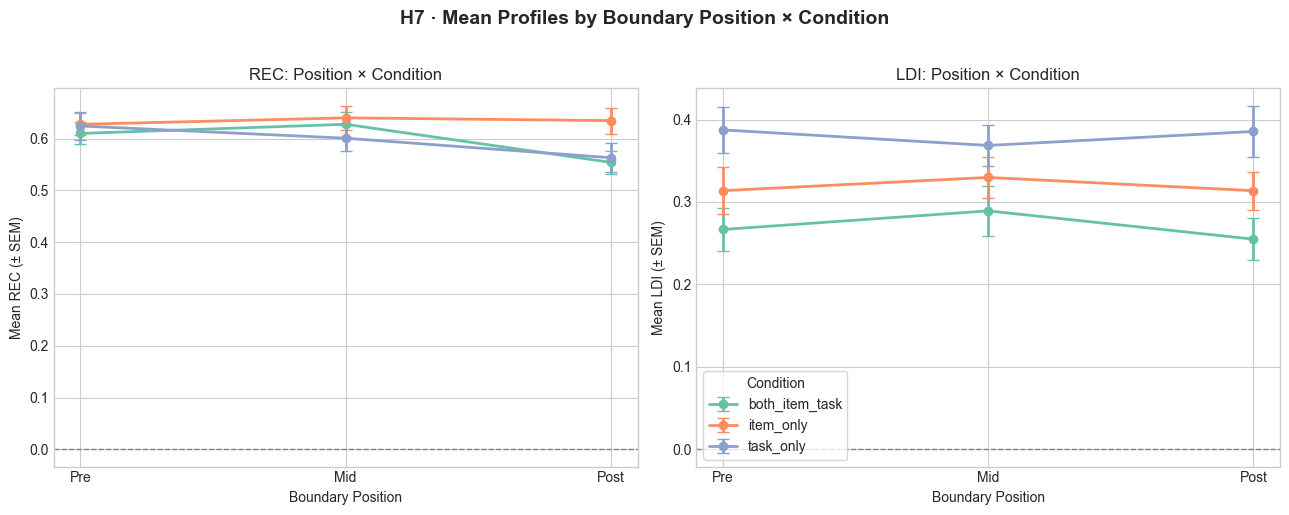

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
fig.suptitle("H7 · Mean Profiles by Boundary Position × Condition",
             fontsize=14, fontweight="bold", y=1.02)

for idx, metric in enumerate(["REC", "LDI"]):
    ax = axes[idx]
    for cond in cond_order:
        sub = position_df[position_df["condition"] == cond]
        means = sub.groupby("boundary_position")[metric].mean().reindex(order)
        sems  = sub.groupby("boundary_position")[metric].sem().reindex(order)
        ax.errorbar(order, means.values, yerr=sems.values,
                    marker="o", linewidth=2, capsize=4, label=cond,
                    color=cond_colors[cond])
    ax.axhline(0, color="gray", linewidth=1, linestyle="--")
    ax.set_title(f"{metric}: Position × Condition", fontsize=12)
    ax.set_xlabel("Boundary Position")
    ax.set_ylabel(f"Mean {metric} (± SEM)")

axes[1].legend(title="Condition", frameon=True, loc="best")
plt.tight_layout()
plt.show()

### 2. Box + Strip Plots
Distribution of individual participant REC/LDI values by boundary position, colored by condition.

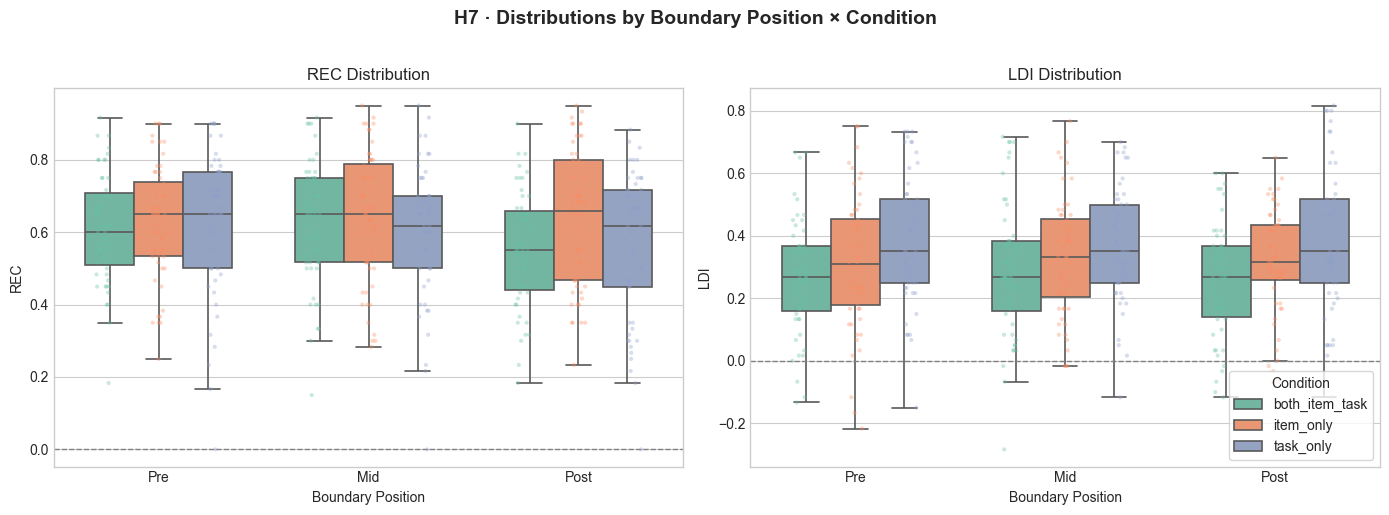

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
fig.suptitle("H7 · Distributions by Boundary Position × Condition",
             fontsize=14, fontweight="bold", y=1.02)

for idx, metric in enumerate(["REC", "LDI"]):
    ax = axes[idx]
    sns.boxplot(data=position_df, x="boundary_position", y=metric,
                hue="condition", order=order, hue_order=cond_order,
                palette=cond_colors, ax=ax, showfliers=False,
                linewidth=1.2, width=0.7)
    sns.stripplot(data=position_df, x="boundary_position", y=metric,
                  hue="condition", order=order, hue_order=cond_order,
                  palette=cond_colors, ax=ax, dodge=True,
                  alpha=0.35, size=3, jitter=True, legend=False)
    ax.axhline(0, color="gray", linewidth=1, linestyle="--")
    ax.set_title(f"{metric} Distribution", fontsize=12)
    ax.set_xlabel("Boundary Position")
    ax.set_ylabel(metric)

handles, labels = axes[1].get_legend_handles_labels()
n = len(cond_order)
axes[1].legend(handles[:n], labels[:n], title="Condition", frameon=True, loc="best")
axes[0].get_legend().remove()

plt.tight_layout()
plt.show()

### 3. Grouped Bar Chart (Mean ± SEM)
Side-by-side bar comparison of mean REC/LDI across boundary positions and conditions.

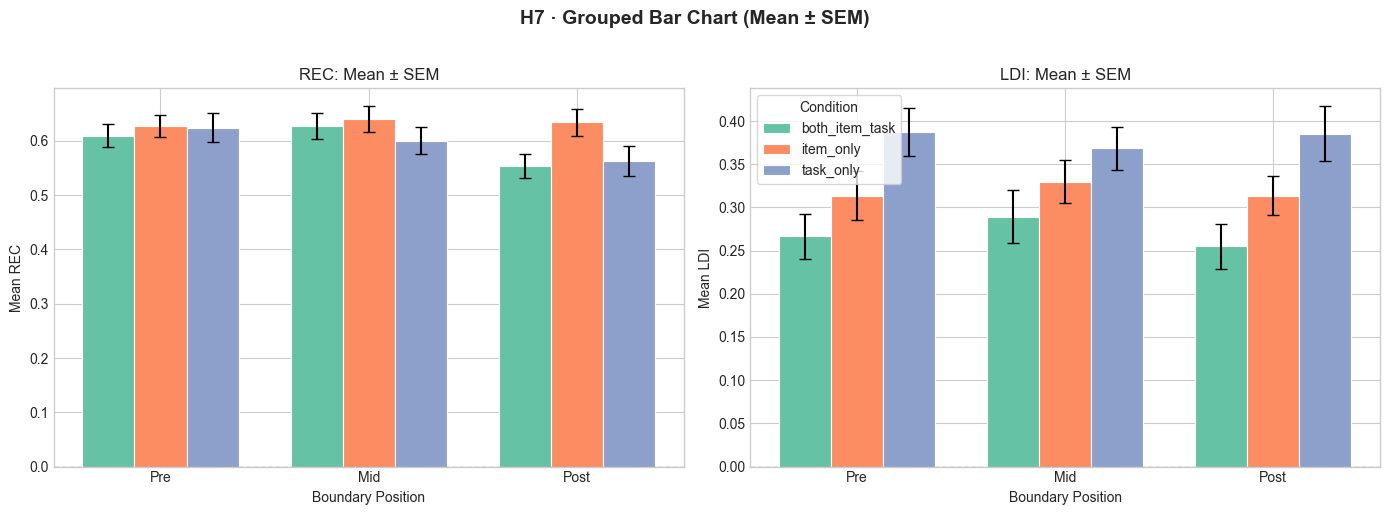

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
fig.suptitle("H7 · Grouped Bar Chart (Mean ± SEM)",
             fontsize=14, fontweight="bold", y=1.02)

for idx, metric in enumerate(["REC", "LDI"]):
    ax = axes[idx]
    summary = (
        position_df.groupby(["condition", "boundary_position"])[metric]
        .agg(["mean", "sem"])
        .reset_index()
    )
    bar_width = 0.25
    x_positions = np.arange(len(order))
    for j, cond in enumerate(cond_order):
        sub = summary[summary["condition"] == cond].set_index("boundary_position").reindex(order)
        ax.bar(x_positions + j * bar_width, sub["mean"].values,
               width=bar_width, yerr=sub["sem"].values, capsize=4,
               label=cond, color=cond_colors[cond], edgecolor="white", linewidth=0.8)
    ax.set_xticks(x_positions + bar_width * (len(cond_order) - 1) / 2)
    ax.set_xticklabels(order)
    ax.axhline(0, color="gray", linewidth=1, linestyle="--")
    ax.set_title(f"{metric}: Mean ± SEM", fontsize=12)
    ax.set_xlabel("Boundary Position")
    ax.set_ylabel(f"Mean {metric}")

axes[1].legend(title="Condition", frameon=True, loc="best")
plt.tight_layout()
plt.show()

### 4. Heatmap
Mean REC/LDI values shown as a color-coded Condition × Position matrix.

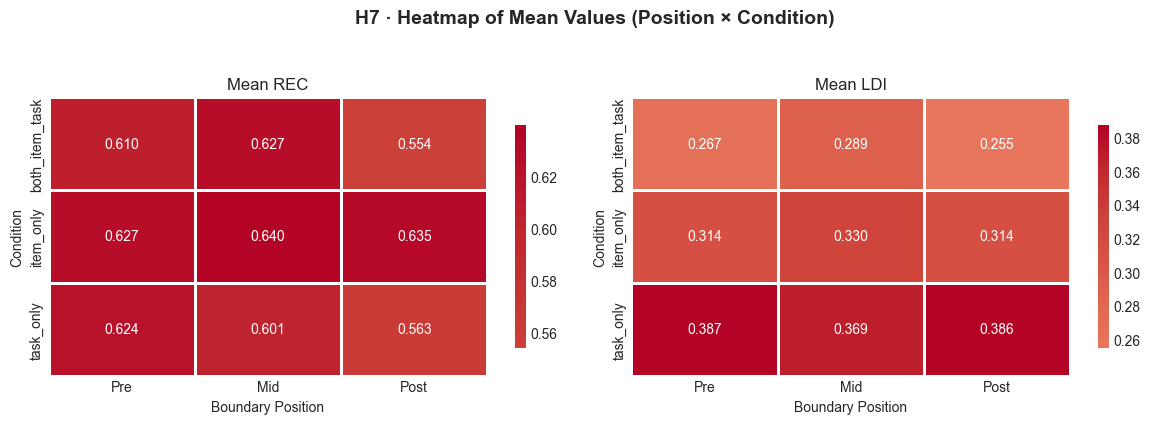

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("H7 · Heatmap of Mean Values (Position × Condition)",
             fontsize=14, fontweight="bold", y=1.05)

for idx, metric in enumerate(["REC", "LDI"]):
    ax = axes[idx]
    pivot = (
        position_df.groupby(["condition", "boundary_position"])[metric]
        .mean()
        .reset_index()
        .pivot(index="condition", columns="boundary_position", values=metric)
        .reindex(index=cond_order, columns=order)
    )
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="coolwarm", center=0,
                linewidths=1, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(f"Mean {metric}", fontsize=12)
    ax.set_xlabel("Boundary Position")
    ax.set_ylabel("Condition")

plt.tight_layout()
plt.show()

### 5. Spaghetti Plot
Individual participant trajectories across boundary positions, with condition means overlaid.

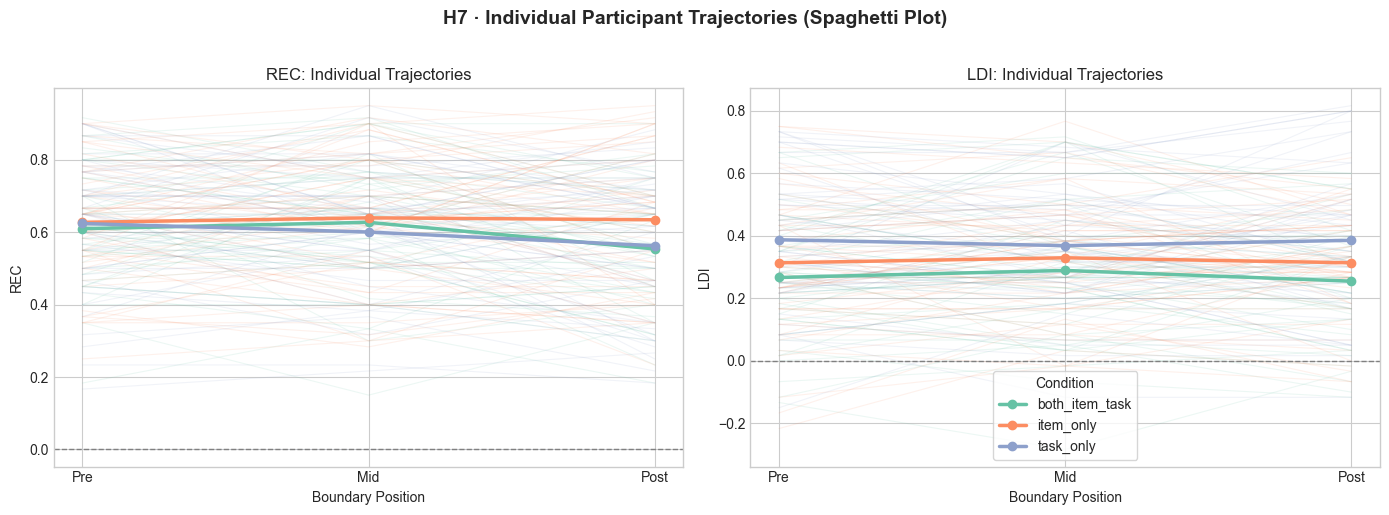

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
fig.suptitle("H7 · Individual Participant Trajectories (Spaghetti Plot)",
             fontsize=14, fontweight="bold", y=1.02)

for idx, metric in enumerate(["REC", "LDI"]):
    ax = axes[idx]
    for cond in cond_order:
        cond_sub = position_df[position_df["condition"] == cond]
        for uid in cond_sub["participant_uid"].unique():
            p_sub = cond_sub[cond_sub["participant_uid"] == uid].set_index("boundary_position").reindex(order)
            ax.plot(order, p_sub[metric].values, alpha=0.12, linewidth=0.8,
                    color=cond_colors[cond])
        # overlay mean
        means = cond_sub.groupby("boundary_position")[metric].mean().reindex(order)
        ax.plot(order, means.values, marker="o", linewidth=2.5,
                color=cond_colors[cond], label=cond, zorder=5)
    ax.axhline(0, color="gray", linewidth=1, linestyle="--")
    ax.set_title(f"{metric}: Individual Trajectories", fontsize=12)
    ax.set_xlabel("Boundary Position")
    ax.set_ylabel(metric)

axes[1].legend(title="Condition", frameon=True, loc="best")
plt.tight_layout()
plt.show()

### 6. Violin Plot
Kernel density distributions of REC/LDI by Position × Condition, with inner quartile lines.

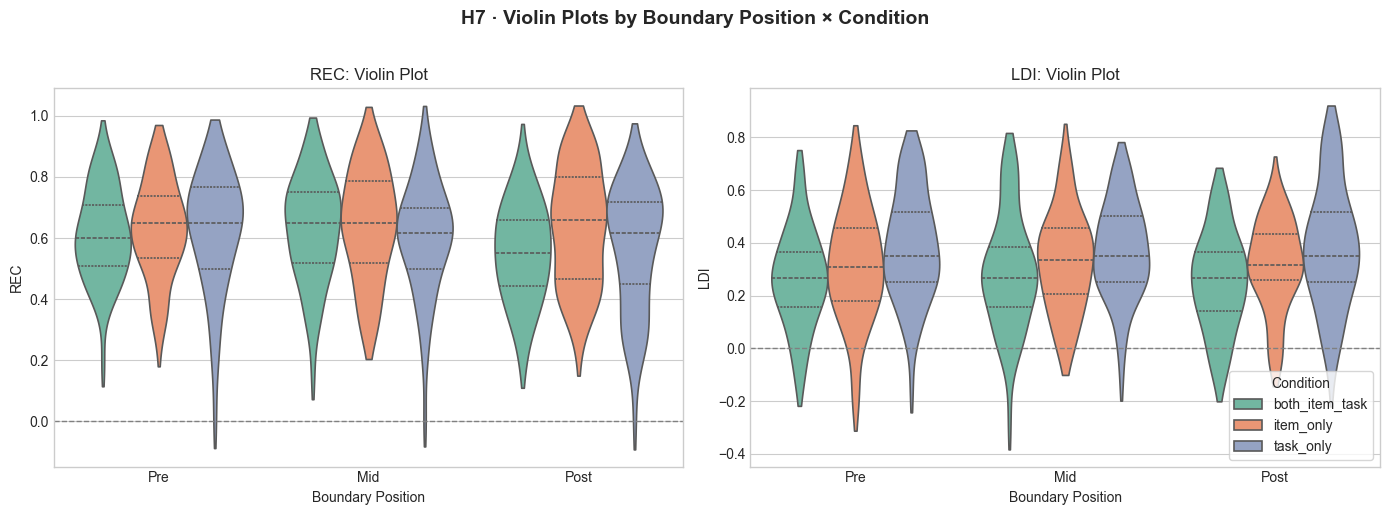

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
fig.suptitle("H7 · Violin Plots by Boundary Position × Condition",
             fontsize=14, fontweight="bold", y=1.02)

for idx, metric in enumerate(["REC", "LDI"]):
    ax = axes[idx]
    sns.violinplot(data=position_df, x="boundary_position", y=metric,
                   hue="condition", order=order, hue_order=cond_order,
                   palette=cond_colors, ax=ax, inner="quartile",
                   linewidth=1.2, cut=1, density_norm="width")
    ax.axhline(0, color="gray", linewidth=1, linestyle="--")
    ax.set_title(f"{metric}: Violin Plot", fontsize=12)
    ax.set_xlabel("Boundary Position")
    ax.set_ylabel(metric)

handles, labels = axes[1].get_legend_handles_labels()
n = len(cond_order)
axes[1].legend(handles[:n], labels[:n], title="Condition", frameon=True, loc="best")
axes[0].get_legend().remove()

plt.tight_layout()
plt.show()